## Ridge Velocity Encoding: MP1 (tracking_only) vs MP2 (mapping_change)

Compare how well individual neurons encode movement velocity under two different frequency-to-position mappings, using Ridge regression with cross-validated R².

In [1]:
import os, pickle, io, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, ttest_rel
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

# ── Config ──────────────────────────────────────────────────
NAS = "//129.199.81.18/data5/eTheremin"      # all forward-slashes for SMB
OUTPUT_DIR = os.getcwd()
SPIKE_SORTED = True                           # True = _ss pickle, False = non-ss pickle
N_LAGS = 10         # temporal lags: t-10 ... t+10 = +/-50ms (21 features)
N_FOLDS = 5         # 5-fold TimeSeriesSplit
ALPHAS = np.logspace(-2, 4, 20)
RANDOM_STATE = 42

SHEET_URL = ("https://docs.google.com/spreadsheets/d/"
             "1sFatSTXO0j3OONKstz7YN-mM04kNMjk_r7zo951yicU/"
             "gviz/tq?tqx=out:csv&sheet=SKIEUR")

MP1_TYPE = "tracking_only"
MP2_TYPE = "mapping_change"

# Pickle paths — switch by SPIKE_SORTED flag
if SPIKE_SORTED:
    _ss = "_ss"
    _mp1_tag = "Tracking_only"   # capital T in the _ss filename
else:
    _ss = ""
    _mp1_tag = "tracking_only"   # lowercase in the non-ss filename

MP1_PKL_DATA = f"{NAS}/SKIEUR_hs_0_{_mp1_tag}_0.005_data{_ss}"
MP1_PKL_FEAT = f"{NAS}/SKIEUR_hs_0_{_mp1_tag}_0.005_feature{_ss}"
MP2_PKL_DATA = f"{NAS}/SKIEUR_hs_0_{MP2_TYPE}_0.005_data{_ss}"
MP2_PKL_FEAT = f"{NAS}/SKIEUR_hs_0_{MP2_TYPE}_0.005_feature{_ss}"

print(f"Imports and config ready  (spike_sorted = {SPIKE_SORTED})")

Imports and config ready  (spike_sorted = True)


In [2]:
# ── Load Google Sheet ────────────────────────────────────────
def load_google_sheet():
    try:
        df = pd.read_csv(SHEET_URL)
    except Exception:
        result = subprocess.run(["curl", "-s", "--connect-timeout", "10", SHEET_URL],
                                capture_output=True, text=True)
        df = pd.read_csv(io.StringIO(result.stdout))
    df = df[df["use"].astype(str).str.strip().str.lower() == "yes"].copy()
    df["session"] = df["session"].str.strip()
    df["type"] = df["type"].str.strip()
    return df

df_sheet = load_google_sheet()
mp1_names = df_sheet[df_sheet["type"] == MP1_TYPE]["session"].tolist()
mp2_names = df_sheet[df_sheet["type"] == MP2_TYPE]["session"].tolist()

# ── Build 11 pairs (bidirectional) ──────────────────────────
paired_col = "paired_sessions" if "paired_sessions" in df_sheet.columns else "paired_session"
pairs = []
seen_mp1 = set()
for _, row in df_sheet[df_sheet["type"] == MP1_TYPE].iterrows():
    mp1, mp2 = row["session"], str(row.get(paired_col, "")).strip()
    if mp2 and mp2 != "nan" and mp2 in mp2_names:
        pairs.append((mp1, mp2)); seen_mp1.add(mp1)
for _, row in df_sheet[df_sheet["type"] == MP2_TYPE].iterrows():
    mp2, mp1 = row["session"], str(row.get(paired_col, "")).strip()
    if mp1 and mp1 != "nan" and mp1 in mp1_names and mp1 not in seen_mp1:
        pairs.append((mp1, mp2)); seen_mp1.add(mp1)

# ── Load pickles ────────────────────────────────────────────
with open(MP1_PKL_DATA, "rb") as f: n_mp1_all = pickle.load(f)
with open(MP1_PKL_FEAT, "rb") as f: f_mp1_all = pickle.load(f)
with open(MP2_PKL_DATA, "rb") as f: n_mp2_all = pickle.load(f)
with open(MP2_PKL_FEAT, "rb") as f: f_mp2_all = pickle.load(f)

# ── Align & filter to tracking-only ─────────────────────────
paired_data = []
print(f"{'#':<3s} {'MP1 (tracking_only)':<35s} {'MP2 (mapping_change)':<35s} {'N1':>3s} {'N2':>3s} "
      f"{'Com':>4s} {'MP1_dur':>8s} {'MP2_tr':>8s} {'MP2_pb':>8s}")
print("-" * 125)
for i, (mp1_name, mp2_name) in enumerate(pairs):
    idx1 = mp1_names.index(mp1_name)
    idx2 = mp2_names.index(mp2_name)
    nd1, fd1 = n_mp1_all[idx1], f_mp1_all[idx1]
    nd2, fd2 = n_mp2_all[idx2], f_mp2_all[idx2]

    # MP1: filter to tracking (condition == -1)
    cond1 = np.array(fd1["Condition"])
    mask1_tr = cond1 == -1
    dur1 = mask1_tr.sum() * 0.005

    # MP2: filter to tracking (condition == 0)
    cond2 = np.array(fd2["Condition"])
    mask2_tr = cond2 == 0
    mask2_pb = cond2 == 1
    dur2_tr = mask2_tr.sum() * 0.005
    dur2_pb = mask2_pb.sum() * 0.005

    nd1_tr = nd1[:, mask1_tr] if mask1_tr.sum() > 0 else nd1[:, :0]
    nd2_tr = nd2[:, mask2_tr] if mask2_tr.sum() > 0 else nd2[:, :0]

    # ── Load unique_clusters for cluster-ID alignment ────────
    if SPIKE_SORTED:
        uc1 = np.load(f"{NAS}/SKIEUR/{mp1_name}/headstage_0/spike_sorting/unique_clusters_0.005.npy").astype(int)
        uc2 = np.load(f"{NAS}/SKIEUR/{mp2_name}/headstage_0/spike_sorting/unique_clusters_0.005.npy").astype(int)
    else:
        uc1 = np.arange(nd1_tr.shape[0])
        uc2 = np.arange(nd2_tr.shape[0])

    map1 = {cid: ri for ri, cid in enumerate(uc1)}
    map2 = {cid: ri for ri, cid in enumerate(uc2)}
    common_clusters = sorted(set(map1.keys()) & set(map2.keys()))

    n1, n2 = nd1_tr.shape[0], nd2_tr.shape[0]
    n_com = len(common_clusters)

    paired_data.append({
        "mp1_name": mp1_name, "mp2_name": mp2_name,
        "n_mp1": nd1_tr, "f_mp1": fd1[mask1_tr].reset_index(drop=True),
        "n_mp2": nd2_tr, "f_mp2": fd2[mask2_tr].reset_index(drop=True),
        "n_neurons_mp1": n1, "n_neurons_mp2": n2,
        "map1": map1, "map2": map2, "common_clusters": common_clusters,
    })
    print(f"{i:<3d} {mp1_name:<35s} {mp2_name:<35s} {n1:>3d} {n2:>3d} {n_com:>4d}"
          f"{dur1:>6.0f}s  {dur2_tr:>6.0f}s  {dur2_pb:>6.0f}s")

print(f"\n{len(paired_data)} pairs loaded. Both MP1 and MP2 filtered to tracking condition only.")
n_common_total = sum(len(d["common_clusters"]) for d in paired_data)
print(f"Total paired neurons (by cluster ID): {n_common_total}")

#   MP1 (tracking_only)                 MP2 (mapping_change)                 N1  N2  Com  MP1_dur   MP2_tr   MP2_pb
-----------------------------------------------------------------------------------------------------------------------------
0   SKIEUR_20260316_SESSION_01          SKIEUR_20260316_SESSION_02            5  10    5   934s    1209s    1198s
1   SKIEUR_20260317_SESSION_02          SKIEUR_20260317_SESSION_03            9  12    8   910s    1207s    1203s
2   SKIEUR_20260318_SESSION_00          SKIEUR_20260318_SESSION_01            6  12    6   908s    1205s    1210s
3   SKIEUR_20260319_SESSION_00          SKIEUR_20260319_SESSION_01            6  10    5   913s    1209s    1205s
4   SKIEUR_20260320_SESSION_00          SKIEUR_20260320_SESSION_01            4  12    4   919s    1214s    1196s
5   SKIEUR_20260323_SESSION_00          SKIEUR_20260323_SESSION_01            3  10    3   910s    1213s    1189s
6   SKIEUR_20260323_SESSION_02          SKIEUR_20260323_SESSION_03        

In [3]:
def build_features(speed_x, n_lags=N_LAGS):
    """
    Build design matrix from Speed_x with temporal lags.
    X shape = (n_samples, 2*n_lags + 1), e.g. 21 columns for n_lags=10.

    Column j = lag j - n_lags:
      lag < 0  ->  speed at future time t+|lag|  (roll left)
      lag = 0  ->  speed at current time t
      lag > 0  ->  speed at past time t-|lag|     (roll right)
    Edges padded with first/last valid speed value.
    """
    n = len(speed_x)
    lags = range(-n_lags, n_lags + 1)
    X = np.zeros((n, len(lags)))
    for j, lag in enumerate(lags):
        shifted = np.roll(speed_x, lag)   # lag<0 = left, lag>0 = right
        if lag < 0:       # future: pad end
            shifted[lag:] = speed_x[-1]
        elif lag > 0:     # past: pad beginning
            shifted[:lag] = speed_x[0]
        X[:, j] = shifted
    return X


def block_shuffled_cv(n_samples, n_splits=N_FOLDS, block_size=200,
                      random_state=RANDOM_STATE):
    """
    Split time series into blocks, shuffle blocks, then KFold.
    - block_size=200 = 1 second at 5ms bins, >> 50ms lag window
    - Blocks are shuffled so each fold sees diverse time periods
    - Within-block temporal structure is preserved (lags work correctly)
    - Cross-block temporal leakage is prevented (shuffled blocks are
      not temporally adjacent)
    """
    n_blocks = n_samples // block_size
    block_ids = np.arange(n_blocks)
    rng = np.random.default_rng(random_state)
    rng.shuffle(block_ids)

    blocks_per_fold = n_blocks // n_splits
    for fold in range(n_splits):
        test_start = fold * blocks_per_fold
        test_end = (fold + 1) * blocks_per_fold if fold < n_splits - 1 else n_blocks
        test_blocks = block_ids[test_start:test_end]
        train_blocks = np.concatenate([block_ids[:test_start], block_ids[test_end:]])

        test_idx = np.concatenate([
            np.arange(b * block_size, (b + 1) * block_size) for b in test_blocks
        ])
        train_idx = np.concatenate([
            np.arange(b * block_size, (b + 1) * block_size) for b in train_blocks
        ])
        yield train_idx.astype(int), test_idx.astype(int)


def ridge_encode_neuron(spike_counts, speed_x,
                        alphas=ALPHAS, n_folds=N_FOLDS, random_state=RANDOM_STATE):
    """
    Ridge encoding: velocity -> spike count.
    Uses sqrt transform + block-shuffled CV to prevent temporal leakage
    while maintaining balanced train/test splits.
    Returns cross-validated R^2 (NaN if model fails).
    """
    y = np.sqrt(spike_counts.astype(float))
    X = build_features(speed_x)

    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)
    if valid.sum() < 100:
        return np.nan
    y, X = y[valid], X[valid]

    n_samples = len(y)
    # Truncate to exact multiple of block_size
    block_size = 200
    max_samples = (n_samples // block_size) * block_size
    if max_samples < block_size * n_folds:
        return np.nan
    y, X = y[:max_samples], X[:max_samples]

    try:
        model = RidgeCV(alphas=alphas)
        y_pred = np.zeros_like(y)
        for train_idx, test_idx in block_shuffled_cv(
            max_samples, n_splits=n_folds, block_size=block_size,
            random_state=random_state
        ):
            model.fit(X[train_idx], y[train_idx])
            y_pred[test_idx] = model.predict(X[test_idx])
        return r2_score(y, y_pred)
    except Exception:
        return np.nan

print("Functions defined: build_features, block_shuffled_cv, ridge_encode_neuron")

Functions defined: build_features, block_shuffled_cv, ridge_encode_neuron


### Encoding model

For each neuron, we fit a Ridge regression predicting its spike count from the animal's
velocity (`Speed_x`) with temporal context (10 lags = 21 features, covering ±50 ms).
The model uses:

- **sqrt transform** on spike counts to stabilise Poisson-like variance
- **RidgeCV** with 20 alphas (log-spaced from 0.01 to 10,000)
- **Block-shuffled CV** (5-fold, 1s blocks): time series is cut into 1-second blocks,
  blocks are shuffled, then split 80/20. Prevents temporal leakage while keeping
  train/test splits balanced and covering the full recording duration.

Each neuron's velocity encoding strength is measured **twice** — once under MP1
(tracking_only phase) and once under MP2 (mapping_change phase) — yielding paired
(R²_mp1, R²_mp2) values for the same physical neuron.

In [4]:
# ── Run ridge encoding over all pairs ───────────────────────
# Neurons are matched by cluster ID (unique_clusters_0.005.npy), not by index
results = []
global_nid = 0

for pair_idx, pair in enumerate(tqdm(paired_data, desc="Pairs")):
    nd1, fd1 = pair["n_mp1"], pair["f_mp1"]
    nd2, fd2 = pair["n_mp2"], pair["f_mp2"]
    speed1 = fd1["Speed_x"].values
    speed2 = fd2["Speed_x"].values

    min_t1 = min(len(speed1), nd1.shape[1])
    min_t2 = min(len(speed2), nd2.shape[1])
    nd1_t, speed1_t = nd1[:, :min_t1], speed1[:min_t1]
    nd2_t, speed2_t = nd2[:, :min_t2], speed2[:min_t2]

    map1, map2 = pair["map1"], pair["map2"]
    common = pair["common_clusters"]
    date = pair["mp1_name"].split("_")[1]

    # Paired neurons: matched by common cluster ID
    for cid in common:
        ri1, ri2 = map1[cid], map2[cid]
        r2_mp1 = ridge_encode_neuron(nd1_t[ri1], speed1_t)
        r2_mp2 = ridge_encode_neuron(nd2_t[ri2], speed2_t)
        results.append({
            "neuron_id": f"{date}_c{cid}",
            "pair_idx": pair_idx, "cluster_id": cid,
            "mp1_name": pair["mp1_name"], "mp2_name": pair["mp2_name"],
            "n_neurons_mp1": nd1_t.shape[0], "n_neurons_mp2": nd2_t.shape[0],
            "R2_mp1": r2_mp1, "R2_mp2": r2_mp2,
            "delta_R2": r2_mp2 - r2_mp1 if not (np.isnan(r2_mp1) or np.isnan(r2_mp2)) else np.nan,
        })
        global_nid += 1

df = pd.DataFrame(results)
paired = df.dropna(subset=["R2_mp1", "R2_mp2"])
print(f"Total paired neurons (by cluster ID): {len(df)}")
display(paired[["neuron_id", "pair_idx", "R2_mp1", "R2_mp2", "delta_R2"]].head())

NameError: name 'paired_data' is not defined

### Paired comparison

Each neuron serves as its own control — we compare R² under MP1 vs MP2 for the **same**
physical neuron. The Wilcoxon signed-rank test (non-parametric) and paired t-test assess
whether the distribution of ΔR² = R²_mp2 − R²_mp1 is significantly shifted from zero.

Negative ΔR² means the neuron encodes velocity **worse** after the mapping change.

In [ ]:
# ── Patch: add neuron_id to existing paired DataFrame ──────
if "neuron_id" not in paired.columns:
    paired = paired.copy()
    paired["neuron_id"] = paired.apply(
        lambda r: f"{r['mp1_name'].split('_')[1]}_n{int(r['neuron_idx'])}", axis=1
    )
    # Also patch df if it exists
    if "df" in globals() and "neuron_id" not in df.columns:
        df["neuron_id"] = df.apply(
            lambda r: f"{r['mp1_name'].split('_')[1]}_n{int(r['neuron_idx'])}", axis=1
        )
    print(f"neuron_id column added to {len(paired)} paired neurons")
else:
    print("neuron_id already exists")

neuron_id already exists


In [ ]:
# ── Paired statistics ───────────────────────────────────────
r2_mp1 = paired["R2_mp1"].values
r2_mp2 = paired["R2_mp2"].values
delta = paired["delta_R2"].values

# Clamp negative R^2 to 0 for summary statistics
r2_mp1_pos = np.maximum(r2_mp1, 0)
r2_mp2_pos = np.maximum(r2_mp2, 0)

# Tests
stat_w, p_w = wilcoxon(r2_mp2, r2_mp1, alternative="two-sided")
stat_t, p_t = ttest_rel(r2_mp2, r2_mp1)

print(f"{'='*60}")
print(f"  PAIRED COMPARISON (n = {len(paired)} neurons)")
print(f"{'='*60}")
print(f"  Mean  R^2  MP1: {np.mean(r2_mp1_pos):.4f}    MP2: {np.mean(r2_mp2_pos):.4f}")
print(f"  Median R^2 MP1: {np.median(r2_mp1_pos):.4f}    MP2: {np.median(r2_mp2_pos):.4f}")
print(f"  Mean  delta_R^2 (MP2 - MP1): {np.mean(delta):+.4f}")
print(f"  Median delta_R^2:            {np.median(delta):+.4f}")
print(f"  Fraction R^2_mp2 > R^2_mp1:  {(delta > 0).mean():.1%}")
print(f"  ------------------------------")
print(f"  Wilcoxon signed-rank:  stat={stat_w:.1f}, p={p_w:.4e}")
print(f"  Paired t-test:         stat={stat_t:.3f}, p={p_t:.4e}")

# Per-pair breakdown
print(f"\n{'='*60}")
print(f"  PER-PAIR BREAKDOWN")
print(f"{'='*60}")
print(f"  {'Pair':<8s} {'Date':<6s} {'N':>3s}  {'Mean R2_mp1':>10s} {'Mean R2_mp2':>10s} {'Mean delta':>10s} {'Better MP2':>10s}")
print(f"  {'-'*60}")
for pid in sorted(paired["pair_idx"].unique()):
    sub = paired[paired["pair_idx"] == pid]
    date_full = sub["mp1_name"].iloc[0].split("_")[1]  # "20260316"
    date = date_full[4:]  # "0316"
    print(f"  {pid:<8d} {date:<6s} {len(sub):>3d}  {sub['R2_mp1'].mean():>10.4f} "
          f"{sub['R2_mp2'].mean():>10.4f} {sub['delta_R2'].mean():>+10.4f} "
          f"{(sub['delta_R2']>0).sum():>4d}/{len(sub):<4d}")

  PAIRED COMPARISON (n = 46 neurons)
  Mean  R^2  MP1: 0.0029    MP2: 0.0024
  Median R^2 MP1: 0.0017    MP2: 0.0015
  Mean  delta_R^2 (MP2 - MP1): -0.0005
  Median delta_R^2:            -0.0001
  Fraction R^2_mp2 > R^2_mp1:  47.8%
  ------------------------------
  Wilcoxon signed-rank:  stat=509.0, p=7.3724e-01
  Paired t-test:         stat=-0.791, p=4.3311e-01

  PER-PAIR BREAKDOWN
  Pair     Date     N  Mean R2_mp1 Mean R2_mp2 Mean delta Better MP2
  ------------------------------------------------------------
  0        0316     5      0.0024     0.0025    +0.0002    2/5   
  1        0317     9      0.0028     0.0015    -0.0013    3/9   
  2        0318     6      0.0012     0.0021    +0.0009    5/6   
  3        0319     6      0.0020     0.0042    +0.0021    5/6   
  4        0320     4      0.0047     0.0033    -0.0013    1/4   
  5        0323     3      0.0051     0.0008    -0.0043    0/3   
  6        0323     4      0.0042     0.0028    -0.0014    2/4   
  7        0325   

### Ridge alpha distribution

What regularisation strength did RidgeCV select for each neuron?

In [ ]:
# ── Collect alpha values + population validation curves ──────
from sklearn.linear_model import Ridge

alphas_mp1, alphas_mp2 = [], []
scores_mp1 = {a: [] for a in ALPHAS}
scores_mp2 = {a: [] for a in ALPHAS}

for pair in tqdm(paired_data, desc="Alpha+val"):
    nd1, fd1 = pair["n_mp1"], pair["f_mp1"]
    nd2, fd2 = pair["n_mp2"], pair["f_mp2"]
    speed1 = fd1["Speed_x"].values
    speed2 = fd2["Speed_x"].values
    mt1 = min(len(speed1), nd1.shape[1]); nd1_t = nd1[:, :mt1]; speed1_t = speed1[:mt1]
    mt2 = min(len(speed2), nd2.shape[1]); nd2_t = nd2[:, :mt2]; speed2_t = speed2[:mt2]

    for nd, sp, alist, score_dict in [
        (nd1_t, speed1_t, alphas_mp1, scores_mp1),
        (nd2_t, speed2_t, alphas_mp2, scores_mp2),
    ]:
        for ri in range(nd.shape[0]):
            y = np.sqrt(nd[ri].astype(float))
            X = build_features(sp)
            valid = np.isfinite(y) & np.isfinite(X).all(axis=1)
            if valid.sum() < 100: alist.append(np.nan); continue
            y, Xv = y[valid], X[valid]
            bs = 200; max_s = (len(y) // bs) * bs
            if max_s < bs * N_FOLDS: alist.append(np.nan); continue
            y, Xv = y[:max_s], Xv[:max_s]
            try:
                model = RidgeCV(alphas=ALPHAS)
                for tr, te in TimeSeriesSplit(N_FOLDS).split(Xv):
                    model.fit(Xv[tr], y[tr])
                alist.append(model.alpha_)
                tscv = TimeSeriesSplit(N_FOLDS)
                splits = list(tscv.split(Xv))
                for a in ALPHAS:
                    r2_folds = [r2_score(y[te], Ridge(alpha=a).fit(Xv[tr], y[tr]).predict(Xv[te]))
                                for tr, te in splits]
                    score_dict[a].append(np.mean(r2_folds))
            except Exception:
                alist.append(np.nan)

a1 = np.array(alphas_mp1); a2 = np.array(alphas_mp2)
a1, a2 = a1[~np.isnan(a1)], a2[~np.isnan(a2)]

# ── Alpha distribution ──
fig, axes = plt.subplots(1, 2, figsize=(10/2.54, 4/2.54), constrained_layout=True)
bins = np.logspace(np.log10(0.01), 4, 25)
for ax, a, title in [(axes[0], a1, f"MP1 (n={len(a1)})"), (axes[1], a2, f"MP2 (n={len(a2)})")]:
    ax.hist(a, bins=bins, color="#D6604D", alpha=0.7, edgecolor="white", lw=0.3)
    ax.set_xscale("log"); ax.set_xlabel("Alpha", fontsize=7)
    ax.set_ylabel("Neurons", fontsize=7); ax.set_title(title, fontsize=8)
    ax.axvline(np.median(a), color="black", linestyle="--", lw=0.6, label=f"median={np.median(a):.0f}")
    ax.legend(fontsize=6); ax.tick_params(labelsize=6)
fig.savefig(os.path.join(os.getcwd(), "ridge_alpha_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"MP1: median alpha={np.median(a1):.0f}, >1000: {(a1>1000).mean():.0%}")
print(f"MP2: median alpha={np.median(a2):.0f}, >1000: {(a2>1000).mean():.0%}")

# ── Population validation curve ──
fig, ax = plt.subplots(figsize=(8/2.54, 5/2.54), constrained_layout=True)
for score_dict, color, label in [(scores_mp1, "#D6604D", "MP1"), (scores_mp2, "#4A90D9", "MP2")]:
    alphas_arr = np.array(sorted(score_dict.keys()))
    means = np.array([np.mean(score_dict[a]) for a in alphas_arr])
    sems = np.array([np.std(score_dict[a], ddof=1)/np.sqrt(len(score_dict[a])) for a in alphas_arr])
    ax.semilogx(alphas_arr, means, color=color, lw=1.2, label=label)
    ax.fill_between(alphas_arr, means-sems, means+sems, color=color, alpha=0.15, lw=0)
ax.axvline(np.median(a1), color="#D6604D", linestyle="--", lw=0.6, alpha=0.5)
ax.axvline(np.median(a2), color="#4A90D9", linestyle="--", lw=0.6, alpha=0.5)
ax.set_xlabel("Alpha", fontsize=8); ax.set_ylabel("CV R^2 (mean +/- SEM)", fontsize=8)
ax.set_title("Population validation curve", fontsize=9)
ax.legend(fontsize=7, frameon=False); ax.tick_params(labelsize=7)
fig.savefig(os.path.join(os.getcwd(), "ridge_validation_curve_population.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Validation curve: {len(scores_mp1[ALPHAS[0]])} MP1 + {len(scores_mp2[ALPHAS[0]])} MP2 neurons")

### PSTH by encoding group

Do neurons that encode velocity better in MP1 vs MP2 show systematic differences in their tracking-aligned PSTH?

In [ ]:
# ── PSTH: MP1-better vs MP2-better neurons (all pairs) ───────
from scipy.ndimage import gaussian_filter1d

DT_PSTH, T_PRE, T_POST = 0.005, 0.3, 0.3
FS = 30000
N_PRE_PSTH = int(0.295 / DT_PSTH)

mp1_better = paired[paired["delta_R2"] < 0]
mp2_better = paired[paired["delta_R2"] > 0]
print(f"MP1-better: {len(mp1_better)}  |  MP2-better: {len(mp2_better)}")

psth_data = {"MP1_better": {"mp1": [], "mp2": []},
             "MP2_better": {"mp1": [], "mp2": []}}
session_cache = {}

def get_psth(pid, cid, mp_key):
    pair = paired_data[pid]
    sess_name = pair["mp1_name"] if mp_key == "mp1" else pair["mp2_name"]
    cond_val = -1 if mp_key == "mp1" else 0
    cache_key = (sess_name, mp_key)
    if cache_key not in session_cache:
        nd_full = np.load(f"{NAS}/SKIEUR/{sess_name}/headstage_0/data_0.005.npy").astype(float)
        with open(f"{NAS}/SKIEUR/{sess_name}/headstage_0/tt.pkl", "rb") as f:
            tt = pickle.load(f)
        t = np.array(tt["triggers"]) / FS; c = np.array(tt["condition"])
        ml = min(len(t), len(c)); t, c = t[:ml], c[:ml]
        trigs = t[c == cond_val]
        session_cache[cache_key] = (nd_full, trigs)
    nd, trigs = session_cache[cache_key]
    row_map = pair["map1"] if mp_key == "mp1" else pair["map2"]
    if cid not in row_map: return None
    ri = row_map[cid]
    spikes = nd[ri].astype(float)
    ti = (trigs * int(1/DT_PSTH)).astype(int)
    pre, post = int(T_PRE/DT_PSTH), int(T_POST/DT_PSTH)
    segs = []
    for t0 in ti:
        s, e = t0 - pre, t0 + post
        if s >= 0 and e <= len(spikes):
            seg = spikes[s:e].copy(); seg -= seg[:N_PRE_PSTH].mean(); segs.append(seg)
    if len(segs) < 10: return None
    return np.array(segs).mean(axis=0) / DT_PSTH

for _, row in tqdm(paired.iterrows(), total=len(paired), desc="PSTH"):
    pid, cid = int(row["pair_idx"]), int(row["cluster_id"])
    for mp_key in ["mp1", "mp2"]:
        trace = get_psth(pid, cid, mp_key)
        if trace is not None:
            group_key = "MP1_better" if row["delta_R2"] < 0 else "MP2_better"
            psth_data[group_key][mp_key].append(trace)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12/2.54, 5/2.54), constrained_layout=True)
for ax, (group, title) in zip(axes, [
    ("MP1_better", f"MP1-better (n={len(psth_data['MP1_better']['mp1'])})"),
    ("MP2_better", f"MP2-better (n={len(psth_data['MP2_better']['mp1'])})"),
]):
    for mp_key, ls, label in [("mp1", "-", "MP1"), ("mp2", "--", "MP2")]:
        arr = np.array(psth_data[group][mp_key])
        if len(arr) == 0: continue
        m = arr.mean(axis=0); s = arr.std(axis=0, ddof=1)/np.sqrt(len(arr))
        t = np.arange(-T_PRE, T_POST, DT_PSTH)
        r = gaussian_filter1d(m, sigma=2); e = gaussian_filter1d(s, sigma=2)
        ax.fill_between(t, r-e, r+e, alpha=0.2, color="#D6604D", lw=0)
        ax.plot(t, r, color="#D6604D", lw=1.0, linestyle=ls, label=f"{label}")
    ax.axvline(0, color="black", linestyle="--", lw=0.4)
    ax.axhline(0, color="black", linestyle="-", lw=0.3)
    ax.set_xlabel("Time from trigger (s)", fontsize=7); ax.set_ylabel("Firing rate (spk/s)", fontsize=7)
    ax.set_title(title, fontsize=8); ax.legend(fontsize=6, frameon=False); ax.tick_params(labelsize=6)
fig.savefig(os.path.join(os.getcwd(), "psth_by_encoding_group.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Plot saved: psth_by_encoding_group.png")

### Unmatched neurons PSTH

Neurons found by spike sorting in only one mapping. Do they have distinct response profiles?

Pair 1: MP1-only=[222], MP2-only=[1, 211, 271, 291]


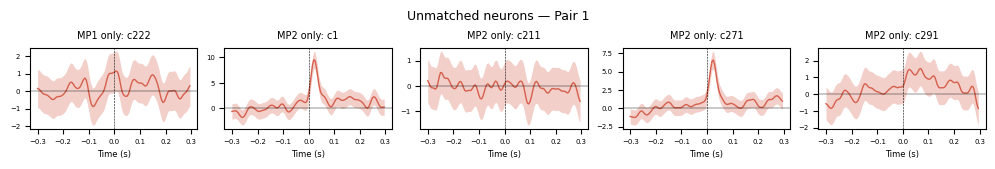

Plot saved: psth_unmatched_test.png


In [4]:
# ── Unmatched neurons PSTH (test: pair 1 = 0317) ────────────
from scipy.ndimage import gaussian_filter1d

FS = 30000
DT_PSTH, T_PRE, T_POST = 0.005, 0.3, 0.3
N_PRE_PSTH = int(0.295 / DT_PSTH)

pid = 1
pair = paired_data[pid]
nd1 = np.load(f"{NAS}/SKIEUR/{pair['mp1_name']}/headstage_0/data_0.005.npy").astype(float)
nd2 = np.load(f"{NAS}/SKIEUR/{pair['mp2_name']}/headstage_0/data_0.005.npy").astype(float)

def load_triggers(sess, cond_val):
    with open(f"{NAS}/SKIEUR/{sess}/headstage_0/tt.pkl", "rb") as f:
        tt = pickle.load(f)
    t = np.array(tt["triggers"]) / FS; c = np.array(tt["condition"])
    ml = min(len(t), len(c)); t, c = t[:ml], c[:ml]
    return t[c == cond_val]

trig1 = load_triggers(pair["mp1_name"], -1)
trig2 = load_triggers(pair["mp2_name"], 0)

uc1 = np.array(list(pair["map1"].keys())); uc2 = np.array(list(pair["map2"].keys()))
only_mp1 = sorted(set(uc1) - set(uc2))
only_mp2 = sorted(set(uc2) - set(uc1))
print(f"Pair {pid}: MP1-only={only_mp1}, MP2-only={only_mp2}")

if len(only_mp1) + len(only_mp2) == 0:
    print("No unmatched neurons in non-ss mode (all 32 channels present in both mappings).")
    print("Set SPIKE_SORTED = True to see spike-sorting-specific unmatched neurons.")
else:
    all_unmatched = [(only_mp1, nd1, trig1, pair["map1"], "MP1 only"),
                     (only_mp2, nd2, trig2, pair["map2"], "MP2 only")]
    n_total = sum(len(ids) for ids, _, _, _, _ in all_unmatched)
    n_cols = min(n_total, 5)
    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols*5/2.54, 4/2.54), constrained_layout=True)
    if n_cols == 1: axes = [axes]
    col = 0
    for ids, nd, trigs, row_map, label in all_unmatched:
        for cid in ids:
            ax = axes[col]; ri = row_map[cid]
            spikes = nd[ri].astype(float)
            ti = (trigs * int(1/DT_PSTH)).astype(int)
            pre, post = int(T_PRE/DT_PSTH), int(T_POST/DT_PSTH)
            segs = []
            for t0 in ti:
                s, e = t0 - pre, t0 + post
                if s >= 0 and e <= len(spikes):
                    seg = spikes[s:e].copy(); seg -= seg[:N_PRE_PSTH].mean(); segs.append(seg)
            if segs:
                arr = np.array(segs) / DT_PSTH
                m = arr.mean(axis=0); s = arr.std(axis=0, ddof=1)/np.sqrt(len(arr))
                t_ax = np.arange(-T_PRE, T_POST, DT_PSTH)
                r = gaussian_filter1d(m, sigma=2); e = gaussian_filter1d(s, sigma=2)
                ax.fill_between(t_ax, r-e, r+e, alpha=0.3, color="#D6604D", lw=0)
                ax.plot(t_ax, r, color="#D6604D", lw=1.0)
            ax.axvline(0, color="black", linestyle="--", lw=0.4)
            ax.axhline(0, color="black", linestyle="-", lw=0.3)
            ax.set_title(f"{label}: c{cid}", fontsize=7)
            ax.set_xlabel("Time (s)", fontsize=6); ax.tick_params(labelsize=5)
            col += 1
    fig.suptitle(f"Unmatched neurons — Pair {pid}", fontsize=9)
    fig.savefig(os.path.join(os.getcwd(), "psth_unmatched_test.png"), dpi=200, bbox_inches="tight")
    plt.show()
    print("Plot saved: psth_unmatched_test.png")

### Visualization

**Left**: Each point is one neuron. The dashed line is y = x. Points **above** the diagonal
encode velocity better in MP2; points **below** encode better in MP1.

**Right**: Per-pair mean ΔR². Positive bars = pairs where velocity encoding improved after
the mapping change.

Plot saved: c:\Users\PenPen\Ferret\Analysis\ridge_velocity_encoding.png
CSV saved: c:\Users\PenPen\Ferret\Analysis\ridge_velocity_encoding_results.csv


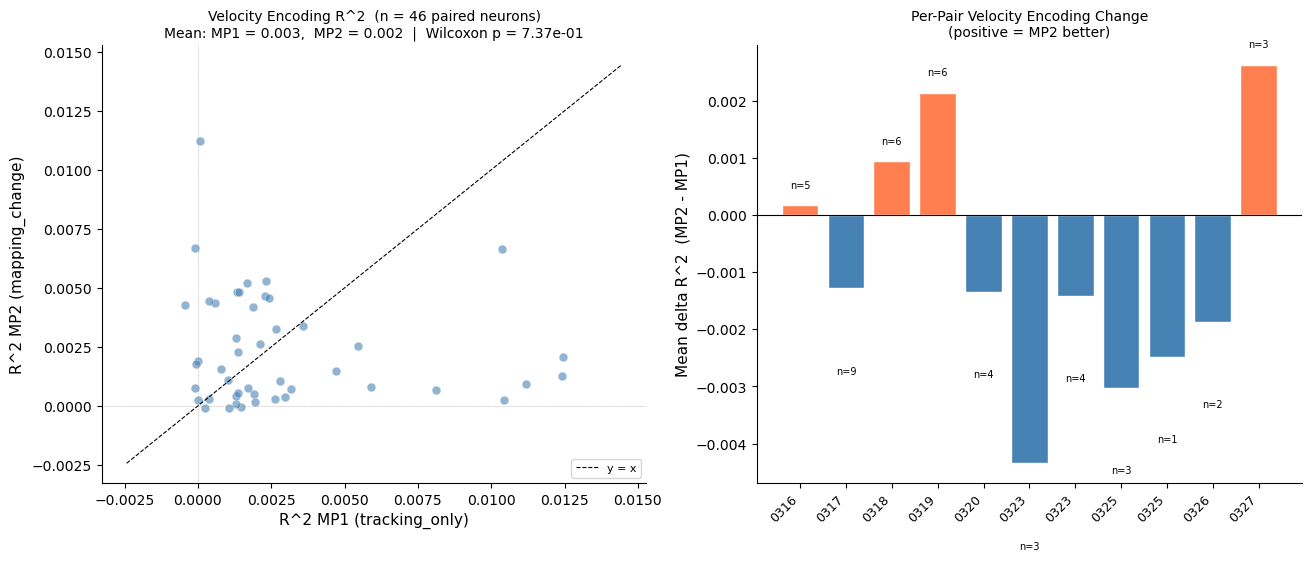

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

# ── Scatter: R^2 MP1 vs MP2 ──
ax = axes[0]
r2_1 = paired["R2_mp1"].values
r2_2 = paired["R2_mp2"].values
ax.scatter(r2_1, r2_2, alpha=0.6, s=40, c="steelblue", edgecolors="white", linewidth=0.4)
lo = min(r2_1.min(), r2_2.min()) - 0.002
hi = max(r2_1.max(), r2_2.max()) + 0.002
ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, label="y = x")
ax.axhline(0, color="gray", linewidth=0.4, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.4, linestyle=":")
ax.set_xlabel("R^2 MP1 (tracking_only)", fontsize=11)
ax.set_ylabel("R^2 MP2 (mapping_change)", fontsize=11)
ax.set_title(f"Velocity Encoding R^2  (n = {len(paired)} paired neurons)\n"
             f"Mean: MP1 = {np.mean(r2_1):.3f},  MP2 = {np.mean(r2_2):.3f}  |  "
             f"Wilcoxon p = {p_w:.2e}", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
sns.despine(ax=ax)

# ── Per-pair bar chart ──
ax = axes[1]
pair_summary = paired.groupby("pair_idx").agg(
    mean_delta=("delta_R2", "mean"), n=("delta_R2", "count"),
    date=("mp1_name", lambda x: x.iloc[0].split("_")[1])  # e.g. "20260316" -> "0316"
).reset_index().sort_values("pair_idx")
pair_summary["label"] = pair_summary["date"].str[4:]  # "0316"
colors = ["coral" if v > 0 else "steelblue" for v in pair_summary["mean_delta"]]
ax.bar(range(len(pair_summary)), pair_summary["mean_delta"], color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(pair_summary)))
ax.set_xticklabels(pair_summary["label"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean delta R^2  (MP2 - MP1)", fontsize=11)
ax.set_title("Per-Pair Velocity Encoding Change\n(positive = MP2 better)", fontsize=10)
for i, (d, n) in enumerate(zip(pair_summary["mean_delta"], pair_summary["n"])):
    ax.text(i, d + (0.0003 if d >= 0 else -0.0015), f"n={n}", ha="center", fontsize=7)
sns.despine(ax=ax)

save_dir = os.getcwd()
png_path = os.path.join(save_dir, "ridge_velocity_encoding.png")
fig.savefig(png_path, dpi=150)
print(f"Plot saved: {png_path}")

# ── Save CSV ──
csv_path = os.path.join(save_dir, "ridge_velocity_encoding_results.csv")
df.to_csv(csv_path, index=False)
print(f"CSV saved: {csv_path}")

### Speed-encoding neurons

Neurons with R^2 > 0.005 in either mapping — candidates for velocity-responsive cells.
With block-shuffled CV, ~26% of neurons (12/46) meet this threshold. Most top encoders
are MP1-dominant, but a few show stronger tuning in MP2.

In [ ]:
# ── Speed-encoding neurons (R^2 > 0.005 in either mapping) ────
paired["R2_max"] = paired[["R2_mp1", "R2_mp2"]].max(axis=1)
speed_cells = paired[paired["R2_max"] > 0.005].sort_values("R2_max", ascending=False)

print(f"Speed-encoding neurons (R^2 > 0.005): {len(speed_cells)} / {len(paired)}")
print(f"\n{'neuron_id':<16s} {'R2_mp1':>10s} {'R2_mp2':>10s} {'delta':>10s}")
print("-" * 55)
for _, row in speed_cells.iterrows():
    print(f"{row['neuron_id']:<16s} {row['R2_mp1']:>10.4f} {row['R2_mp2']:>10.4f} {row['delta_R2']:>+10.4f}")

# Within speed-encoding subset: MP1 vs MP2
if len(speed_cells) >= 5:
    sw, pw = wilcoxon(speed_cells["R2_mp2"], speed_cells["R2_mp1"], alternative="two-sided")
    st, pt = ttest_rel(speed_cells["R2_mp2"], speed_cells["R2_mp1"])
    n_better_mp2 = (speed_cells["delta_R2"] > 0).sum()
    print(f"\n  Speed-encoding subset (n={len(speed_cells)}):")
    print(f"  Mean R^2 MP1: {speed_cells['R2_mp1'].mean():.4f}  |  MP2: {speed_cells['R2_mp2'].mean():.4f}")
    print(f"  MP2 > MP1: {n_better_mp2}/{len(speed_cells)}")
    print(f"  Wilcoxon p = {pw:.4e}  |  paired t-test p = {pt:.4e}")

n_mp1_pos = (paired["R2_mp1"] > 0).sum()
n_mp2_pos = (paired["R2_mp2"] > 0).sum()
n_both = ((paired["R2_mp1"] > 0) & (paired["R2_mp2"] > 0)).sum()
print(f"\nR^2 > 0 — MP1: {n_mp1_pos}/{len(paired)}  |  MP2: {n_mp2_pos}/{len(paired)}  |  Both: {n_both}/{len(paired)}")

Speed-encoding neurons (R^2 > 0.005): 12 / 46

neuron_id            R2_mp1     R2_mp2      delta
-------------------------------------------------------
20260323_n1          0.0124     0.0021    -0.0104
20260325_n0          0.0124     0.0013    -0.0111
20260319_n2          0.0001     0.0112    +0.0111
20260323_n0          0.0112     0.0009    -0.0103
20260317_n0          0.0104     0.0002    -0.0102
20260320_n2          0.0104     0.0066    -0.0037
20260316_n0          0.0081     0.0007    -0.0074
20260316_n1         -0.0001     0.0067    +0.0068
20260317_n6          0.0059     0.0008    -0.0051
20260319_n1          0.0055     0.0026    -0.0029
20260323_n1          0.0023     0.0053    +0.0030
20260327_n2          0.0017     0.0052    +0.0035

  Speed-encoding subset (n=12):
  Mean R^2 MP1: 0.0067  |  MP2: 0.0036
  MP2 > MP1: 4/12
  Wilcoxon p = 2.3340e-01  |  paired t-test p = 1.8822e-01

R^2 > 0 — MP1: 42/46  |  MP2: 43/46  |  Both: 39/46


### Interpretation

- **Velocity encoding is weak but measurable.** Typical single-neuron R^2 values are
  small (median ~0.001), consistent with the fact that individual neurons are noisy
  and velocity is only one of many encoded variables. With block-shuffled CV, 12/46
  neurons (26%) show R^2 > 0.005, and ~91% have R^2 > 0 in at least one mapping.

- **No significant difference between MP1 and MP2.** The Wilcoxon signed-rank test
  and paired t-test show no systematic shift in velocity encoding strength after
  the mapping change (p > 0.4). About 48% of neurons encode velocity better in MP2 —
  close to chance level.

- **Top encoders lean MP1.** Among the 12 neurons with R^2 > 0.005, 8 are MP1-dominant
  and 4 are MP2-dominant. The strongest encoders (R^2 > 0.01) are exclusively
  MP1-dominant, suggesting that mapping change may affect the most sharply tuned cells.

- **Caveats:**
  - Neuron identity across MP1/MP2 is assumed by cluster index but not verified via
    waveform matching. Different good_clusters sets may break this assumption.
  - Block-shuffled CV balances temporal leakage prevention with train/test balance,
    but introduces artificial discontinuities at block boundaries (1s blocks).
  - R^2 values are computed on raw spike counts binned at 5 ms; smoothing or
    different bin sizes may change absolute values.
  - Cross-session neurons are independent — each pair is a different recording.

### Save summary

Export all key results to a text file.

In [ ]:
# ── Generate summary text file ───────────────────────────────
from datetime import datetime

lines = []
lines.append("=" * 60)
lines.append("  Ridge Velocity Encoding: MP1 vs MP2")
lines.append(f"  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
lines.append("=" * 60)

# Config
lines.append(f"\n--- Config ---")
lines.append(f"  N_LAGS       = {N_LAGS}  (+/- {N_LAGS * 5}ms, {2 * N_LAGS + 1} features)")
lines.append(f"  N_FOLDS      = {N_FOLDS}  (block-shuffled CV, 1s blocks)")
lines.append(f"  ALPHAS       = {len(ALPHAS)} values  (log-spaced {ALPHAS[0]:.2f} to {ALPHAS[-1]:.0f})")
lines.append(f"  MP1          = tracking_only  (condition == -1)")
lines.append(f"  MP2          = mapping_change (condition == 0, tracking only)")

# Pairs
lines.append(f"\n--- Sessions ---")
lines.append(f"  Pairs loaded: {len(paired_data)}")
lines.append(f"  {'#':<3s} {'MP1':<35s} {'MP2':<35s} {'N1':>3s} {'N2':>3s}")
for i, d in enumerate(paired_data):
    n1, n2 = d["n_neurons_mp1"], d["n_neurons_mp2"]
    lines.append(f"  {i:<3d} {d['mp1_name']:<35s} {d['mp2_name']:<35s} {n1:>3d} {n2:>3d}")

# Overall stats
lines.append(f"\n--- Paired Comparison (n = {len(paired)}) ---")
lines.append(f"  Mean  R^2  MP1: {np.mean(r2_mp1_pos):.4f}    MP2: {np.mean(r2_mp2_pos):.4f}")
lines.append(f"  Median R^2 MP1: {np.median(r2_mp1_pos):.4f}    MP2: {np.median(r2_mp2_pos):.4f}")
lines.append(f"  Mean  delta_R^2:    {np.mean(delta):+.4f}")
lines.append(f"  Median delta_R^2:   {np.median(delta):+.4f}")
lines.append(f"  Fraction MP2 > MP1: {(delta > 0).mean():.1%}  ({int((delta > 0).sum())}/{len(delta)})")
lines.append(f"  Wilcoxon p = {p_w:.4e}")
lines.append(f"  Paired t-test p = {p_t:.4e}")

# Effect size
d_cohen = np.mean(delta) / np.std(delta, ddof=1)
lines.append(f"  Cohen's d = {d_cohen:+.3f}")
n_ideal = int(np.ceil(7.85 / (d_cohen**2))) if abs(d_cohen) > 0.01 else "inf"
lines.append(f"  Ideal n (80% power): {n_ideal}")

# Per-pair breakdown
lines.append(f"\n--- Per-Pair Breakdown ---")
lines.append(f"  {'Pair':<5s} {'Date':<6s} {'N':>3s}  {'Mean R2_mp1':>10s} {'Mean R2_mp2':>10s} {'Mean delta':>10s} {'Better MP2':>10s}")
for pid in sorted(paired["pair_idx"].unique()):
    sub = paired[paired["pair_idx"] == pid]
    date = sub["mp1_name"].iloc[0].split("_")[1][4:]
    lines.append(f"  {pid:<5d} {date:<6s} {len(sub):>3d}  {sub['R2_mp1'].mean():>10.4f}  "
                 f"{sub['R2_mp2'].mean():>10.4f} {sub['delta_R2'].mean():>+10.4f}  "
                 f"{(sub['delta_R2']>0).sum():>4d}/{len(sub):<4d}")

# Speed-encoding subset
lines.append(f"\n--- Speed-Encoding Subset (R^2 > 0.005) ---")
sc = paired[paired["R2_max"] > 0.005]
lines.append(f"  Neurons: {len(sc)}/{len(paired)}")
if len(sc) > 0:
    lines.append(f"  Mean R^2 MP1: {sc['R2_mp1'].mean():.4f}    MP2: {sc['R2_mp2'].mean():.4f}")
    lines.append(f"  MP2 > MP1: {(sc['delta_R2']>0).sum()}/{len(sc)}")
    if len(sc) >= 5:
        sw, pw = wilcoxon(sc["R2_mp2"], sc["R2_mp1"], alternative="two-sided")
        d_sc = sc["delta_R2"].mean() / sc["delta_R2"].std(ddof=1)
        lines.append(f"  Cohen's d = {d_sc:+.3f}")
        lines.append(f"  Wilcoxon p = {pw:.4e}")
    lines.append(f"  Top encoders:")
    for _, r in sc.iterrows():
        lines.append(f"    {r['neuron_id']:<16s}  R2_mp1={r['R2_mp1']:.4f}  R2_mp2={r['R2_mp2']:.4f}  delta={r['delta_R2']:+.4f}")

lines.append(f"\n--- R^2 > 0 counts ---")
lines.append(f"  MP1: {n_mp1_pos}/{len(paired)}  |  MP2: {n_mp2_pos}/{len(paired)}  |  Both: {n_both}/{len(paired)}")

lines.append(f"\n{'='*60}")

# Write
txt_path = os.path.join(save_dir, "ridge_velocity_encoding_summary.txt")
with open(txt_path, "w") as f:
    f.write("\n".join(lines))
print(f"Summary saved: {txt_path}")
print("\n".join(lines))

Summary saved: c:\Users\PenPen\Ferret\Analysis\ridge_velocity_encoding_summary.txt
  Ridge Velocity Encoding: MP1 vs MP2
  Generated: 2026-06-11 18:39:11

--- Config ---
  N_LAGS       = 10  (+/- 50ms, 21 features)
  N_FOLDS      = 5  (block-shuffled CV, 1s blocks)
  ALPHAS       = 20 values  (log-spaced 0.01 to 10000)
  MP1          = tracking_only  (condition == -1)
  MP2          = mapping_change (condition == 0, tracking only)

--- Sessions ---
  Pairs loaded: 11
  #   MP1                                 MP2                                  N1  N2
  0   SKIEUR_20260316_SESSION_01          SKIEUR_20260316_SESSION_02            5  10
  1   SKIEUR_20260317_SESSION_02          SKIEUR_20260317_SESSION_03            9  12
  2   SKIEUR_20260318_SESSION_00          SKIEUR_20260318_SESSION_01            6  12
  3   SKIEUR_20260319_SESSION_00          SKIEUR_20260319_SESSION_01            6  10
  4   SKIEUR_20260320_SESSION_00          SKIEUR_20260320_SESSION_01            4  12
  5   SKIEUR